<a href="https://colab.research.google.com/github/arun-arunisto/Python-Education/blob/todo/HandlingGeoSpatialDataWithGeoPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Geospatial Data

Geospatial data, also known as geodata, is information that's associated with a location on Earth. It can include information about physical or imaginary features, such as:
Boundaries, Location information, Mobility data, Natural phenomena, Points of interest, Statistical information, and Weather patterns.


There are many, many different geospatial file formats, such as shapefile, GeoJSON, KML, and GPKG.

***GeoPandas***

GeoPandas is an open source project to make working with geospatial data in python easier. GeoPandas extends the datatypes used by pandas to allow spatial operations on geometric types. Geometric operations are performed by shapely. Geopandas further depends on pyogrio for file access and matplotlib for plotting.

### Using GeoPandas to reading Geospatial data



In [1]:
#importing geopandas library
import geopandas as gpd

Here we're going to read a shape file containing information about forests, wilderness areas and other lands under the `Department od Enviromental Conservation` in the state of New York.

In [2]:
#rading the data
full_data = gpd.read_file("/content/drive/MyDrive/data/DEC_lands/DEC_lands/DEC_lands.shp")

In [3]:
#to view the first five data
full_data.head()

,OBJECTID,CATEGORY,UNIT,FACILITY,CLASS,UMP,DESCRIPTIO,REGION,COUNTY,URL,SOURCE,UPDATE_,OFFICE,ACRES,LANDS_UID,GREENCERT,SHAPE_AREA,SHAPE_LEN,geometry
0,1,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,None,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,738.620192,103,N,2.990365e+06,7927.662385,"POLYGON ((486093.245 4635308.586, 486787.235 4..."
1,2,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,None,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,282.553140,1218,N,1.143940e+06,4776.375600,"POLYGON ((491931.514 4637416.256, 491305.424 4..."
2,3,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,None,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,234.291262,1780,N,9.485476e+05,5783.070364,"POLYGON ((486000.287 4635834.453, 485007.55 46..."
3,4,FOR PRES DET PAR,CFP,GREENE COUNTY FP DETACHED PARCEL,WILD FOREST,None,None,4,GREENE,http://www.dec.ny.gov/,GREENE RPP,5/12,STAMFORD,450.106464,2060,N,1.822293e+06,7021.644833,"POLYGON ((541716.775 4675243.268, 541217.58 46..."
4,6,FOREST PRESERVE,AFP,SARANAC LAKES WILD FOREST,WILD FOREST,SARANAC LAKES,None,5,ESSEX,http://www.dec.ny.gov/lands/22593.html,"DECRP, ESSEX RPP",12/96,RAY BROOK,69.702387,1517,N,2.821959e+05,2663.909932,"POLYGON ((583896.043 4909643.187, 583891.2 490..."


If we load a shape file into geopandas it will become a ***GeoDataFrame*** object like pandas dataframe

In [4]:
#checking the type
type(full_data)

geopandas.geodataframe.GeoDataFrame

From the above table we're not going to use the full columns, we can select a subset of them like pandas

In [5]:
data = full_data.loc[:, ["CLASS", "COUNTY", "geometry"]].copy()

`value_counts` this method is used to see a different types of data, along with how many times they appear in the dataset. (similar to pandas). We will use this method on `CLASS` column

In [6]:
# value counts
data.CLASS.value_counts()

,count
CLASS,
WILD FOREST,965
INTENSIVE USE,108
PRIMITIVE,60
WILDERNESS,52
ADMINISTRATIVE,17
UNCLASSIFIED,7
HISTORIC,5
PRIMITIVE BICYCLE CORRIDOR,4
CANOE AREA,1


And also we can use `loc`, `iloc`, and `isin` to select subsets of the data. (similar like pandas)

In [7]:
#selecting lands falls under the "wild forest" or "wilderness" category
wild_lands = data.loc[data.CLASS.isin(["WILDERNESS", "wILD FOREST"])].copy()
wild_lands.head()

,CLASS,COUNTY,geometry
45,WILDERNESS,FRANKLIN,"POLYGON ((554752.502 4896638.367, 554694.415 4..."
93,WILDERNESS,ULSTER,"POLYGON ((549961.449 4663087.382, 549964.601 4..."
113,WILDERNESS,HAMILTON,"POLYGON ((554668.249 4881707.5, 554662.25 4881..."
479,WILDERNESS,ST. LAWRENCE,"POLYGON ((527383.561 4887145.5, 527401.435 488..."
497,WILDERNESS,ESSEX,"POLYGON ((572855.188 4914160.5, 572839.313 491..."


`plot()` method used to visualize the data, like below

<Axes: >

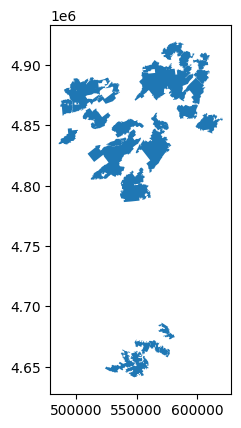

In [8]:
wild_lands.plot()

All ***GeoDataFrame*** contains a special "geometry" column. It contains all of the geometric objects that are displayed when we call the `plot()` method.

In [9]:
#reading the five data from geometry column
wild_lands.geometry.head()

,geometry
45,"POLYGON ((554752.502 4896638.367, 554694.415 4..."
93,"POLYGON ((549961.449 4663087.382, 549964.601 4..."
113,"POLYGON ((554668.249 4881707.5, 554662.25 4881..."
479,"POLYGON ((527383.561 4887145.5, 527401.435 488..."
497,"POLYGON ((572855.188 4914160.5, 572839.313 491..."


`geometry` can contain a variety of different data types, each entry will typically be a ***Point***, ***LineString***, or ***Polygon***

For `Point` we are going to load GeoDataFrame containing all the  campsites locations in New York

In [10]:
#Campsites in new york
POI_data = gpd.read_file("/content/drive/MyDrive/data/DEC_pointsinterest/DEC_pointsinterest/Decptsofinterest.shp")

In [11]:
POI_data.head()

,OBJECTID,UNIT,FACILITY,NAME,ASSET,DESCRIP,REGION,OFFICE,UPDATED,ASSET_UID,ACCESSIBLE,geometry
0,91706,CFP,DELAWARE WILD FOREST,ADA PRIMITIVE CAMPSITE,PRIMITIVE CAMPSITE,None,4,STAMFORD,2016/09/26,16519,N,POINT (505138.696 4649388.247)
1,108646,SCHUYLER 02,SUGAR HILL STATE FOREST,MAPLE LANE CAMPSITE #3,PRIMITIVE CAMPSITE,None,8,BATH,2018/02/23,18124,N,POINT (333481.874 4692737.8)
2,19933,AFP,MOOSE RIVER PLAINS WILD FOREST,MOOSE RIVER PLAINS CAMPSITE 103,PRIMITIVE CAMPSITE,LIVE,5,NORTHVILLE,2010/06/16,1018,N,POINT (525210.784 4833837.295)
3,3945,ALLEGANY 12,LOST NATION STATE FOREST,NEWLAND FR PARKING,UNPAVED PARKING LOT,-99,9,WEST ALMOND,0000/00/00,8623,N,POINT (231909.125 4712818.5)
4,1037,CATTARAUGUS 08,ROCK CITY STATE FOREST,LRC PICNIC PAVILION #1,PICNIC PAVILION,None,9,ALLEGANY,0000/00/00,14561,N,POINT (193656.734 4679632.5)


In [12]:
#filtering point type
campsites = POI_data.loc[POI_data.ASSET=="PRIMITIVE CAMPSITE"].copy()

For `LineString` type we are going to load the DataFrame containing all the foot trails in New York state

In [13]:
#foot trails in new york state
roads_trails = gpd.read_file("/content/drive/MyDrive/data/DEC_roadstrails/DEC_roadstrails/Decroadstrails.shp")

In [14]:
roads_trails.head()

,OBJECTID,UNIT,FACILITY,NAME,ASSET,ATV,FOOT,HORSE,BIKE,XC,...,MAPPWD,DESCRIP,ROAD_CLASS,UPDATED,REGION,OFFICE,MARKER,TRANS_UID,SHAPE_LEN,geometry
0,208,AFP,FERRIS LAKE WILD FOREST,PHANTOM TRAIL,SNOWMOBILE TRAIL,N,Y,N,N,Y,...,N,None,RT,2011/05/17,5,NORTHVILLE,None,1583.181399,1577.112643,"LINESTRING (511367.312 4804744, 511442.406 480..."
1,211,AFP,FERRIS LAKE WILD FOREST,PHANTOM TRAIL,SNOWMOBILE TRAIL,N,Y,N,N,Y,...,N,None,RT,2011/05/17,5,NORTHVILLE,None,948.150638,945.366235,"LINESTRING (512806.962 4804560.806, 512796.625..."
2,212,AFP,FERRIS LAKE WILD FOREST,PARKER VLY TRAIL,SNOWMOBILE TRAIL,N,Y,N,N,Y,...,N,None,RT,2011/05/17,5,NORTHVILLE,None,3862.887604,3853.119292,"MULTILINESTRING ((515866.032 4804650.001, 5158..."
3,229,AFP,FERRIS LAKE WILD FOREST,WAGONERS LOOP,SNOWMOBILE TRAIL,N,Y,Y,Y,Y,...,N,None,RT,2011/05/17,5,NORTHVILLE,None,10536.778083,10485.458536,"LINESTRING (533975.501 4796126.5, 533992.812 4..."
4,233,AFP,FERRIS LAKE WILD FOREST,SHERIFF LAKE TRAIL,SNOWMOBILE TRAIL,N,Y,Y,Y,Y,...,N,None,RT,2011/05/17,5,NORTHVILLE,None,1439.438752,1432.490031,"LINESTRING (531496.7 4799892.919, 531482.375 4..."


In [15]:
#filtering linestring type
trails = roads_trails.loc[roads_trails.ASSET == "FOOT TRAIL"].copy()

For `Polygon` type we're going to use the data of county boundaries data of New York

In [16]:
#county boundaries in the new york state polygon type
counties = gpd.read_file("/content/drive/MyDrive/data/NY_county_boundaries/NY_county_boundaries/NY_county_boundaries.shp")

In [17]:
counties.head()

,STATE,COUNTY,NAME,LSAD,LSAD_TRANS,OID_,COUNTY_FIP,POP2000,WHITE,BLACK,...,FHH_MINORC,FAMILIES,AV_FAM_SZ,HSE_UNITS,URBAN,RURAL,VACANT,OWNER_OCC,RENTER_OCC,geometry
0,36,089,St. Lawrence,06,County,44,089,111931,105782,2664,...,2773,26939,3,49721,16085,33636,9215,28606,11900,"POLYGON ((522686.116 4977770.435, 522785.82 49..."
1,36,019,Clinton,06,County,9,019,79894,74562,2863,...,1951,19261,3,33091,12161,20930,3668,20157,9266,"POLYGON ((576869.554 4981194.984, 576661.323 4..."
2,36,033,Franklin,06,County,16,033,51134,42970,3389,...,1312,11805,3,23936,7409,16527,6005,12638,5293,"POLYGON ((576869.554 4981194.984, 577209.259 4..."
3,36,031,Essex,06,County,15,031,38851,36848,1092,...,810,9832,3,23115,4288,18827,8087,11089,3939,"POLYGON ((622025.362 4932488.545, 621958.049 4..."
4,36,045,Jefferson,06,County,22,045,111738,99118,6517,...,2815,28142,3,54070,20947,33123,14002,23906,16162,"POLYGON ((431513.316 4917024.86, 433126.724 49..."


Actually in `plot()` method there are many parameters, we can use that to customize the appearance. Like by using the `Polygon` data we can create a map like below.

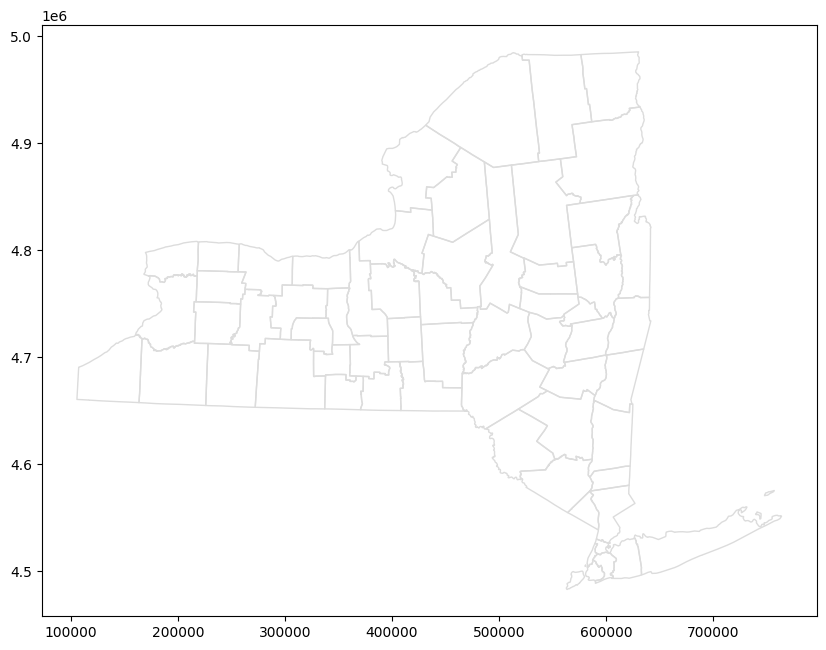

In [18]:
ax = counties.plot(figsize=(10, 10), color="None", edgecolor="gainsboro")

And also we can plot the data into this map like below

<Axes: >

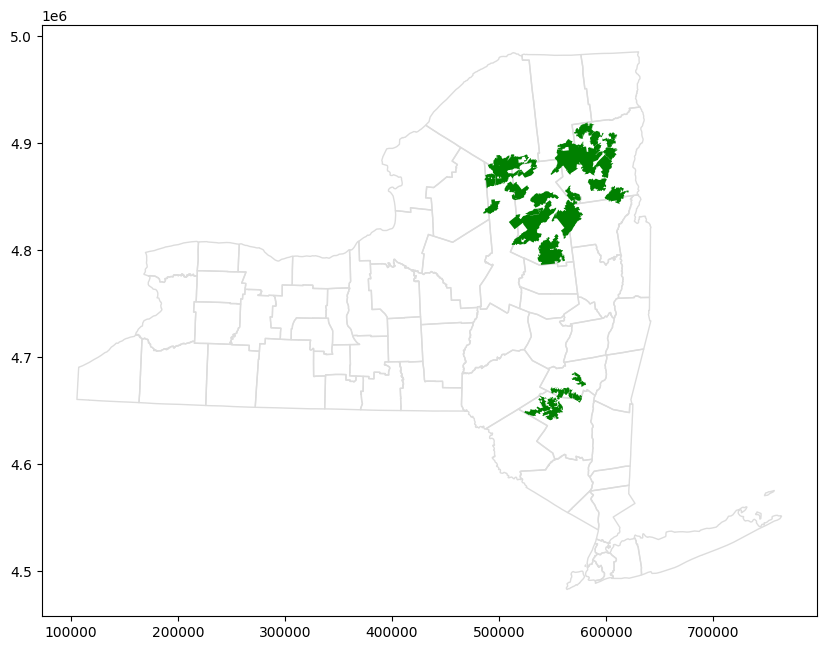

In [19]:
ax = counties.plot(figsize=(10, 10), color="None", edgecolor="gainsboro")
#plotting the wild_lands
wild_lands.plot(color="green", ax=ax)

<Axes: >

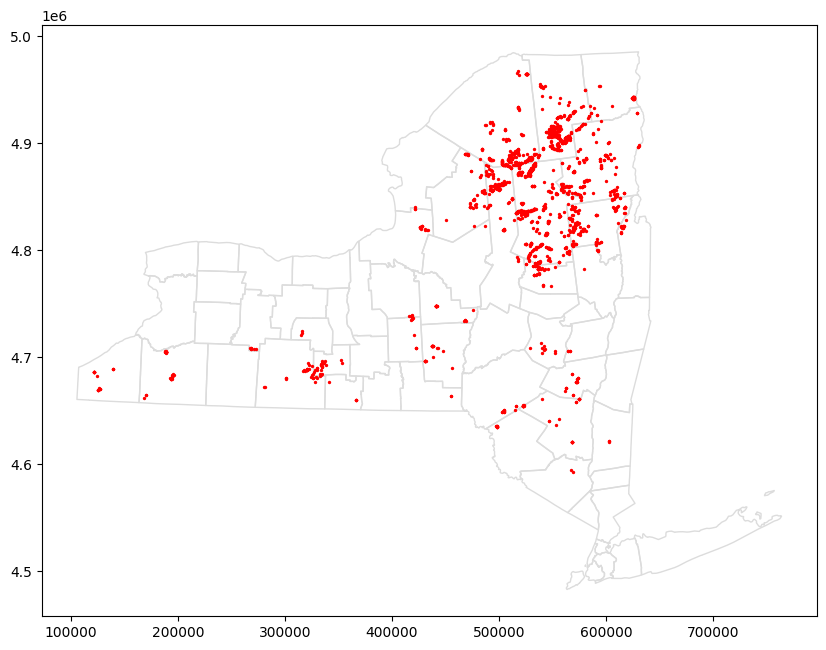

In [20]:
ax = counties.plot(figsize=(10, 10), color="None", edgecolor="gainsboro")
#plotting campsites
campsites.plot(color="red", markersize=2, ax=ax)

<Axes: >

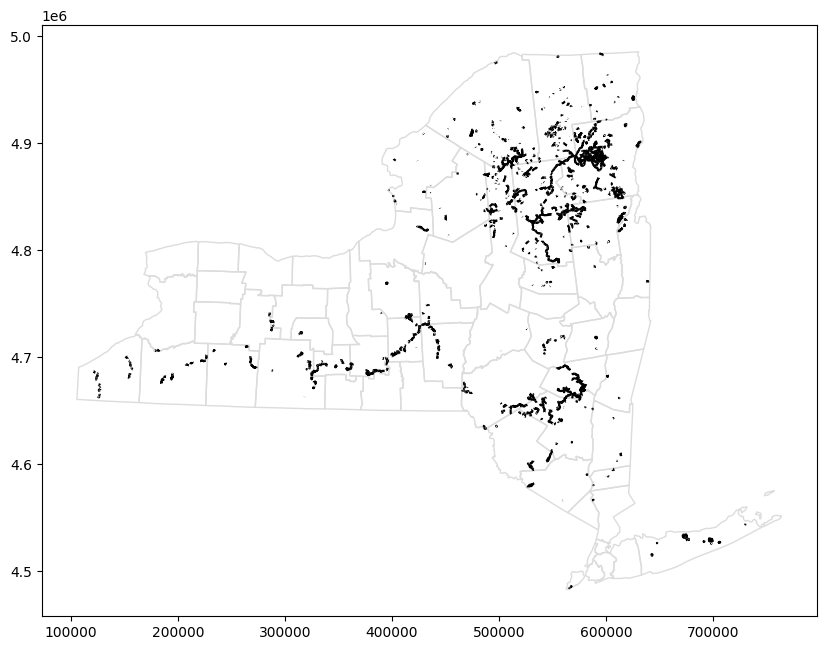

In [21]:
ax = counties.plot(figsize=(10, 10), color="None", edgecolor="gainsboro")
#plotting foot trails data
trails.plot(color="black", markersize=1, ax=ax)

And also in the same map we can plot multiple information together like below.

<Axes: >

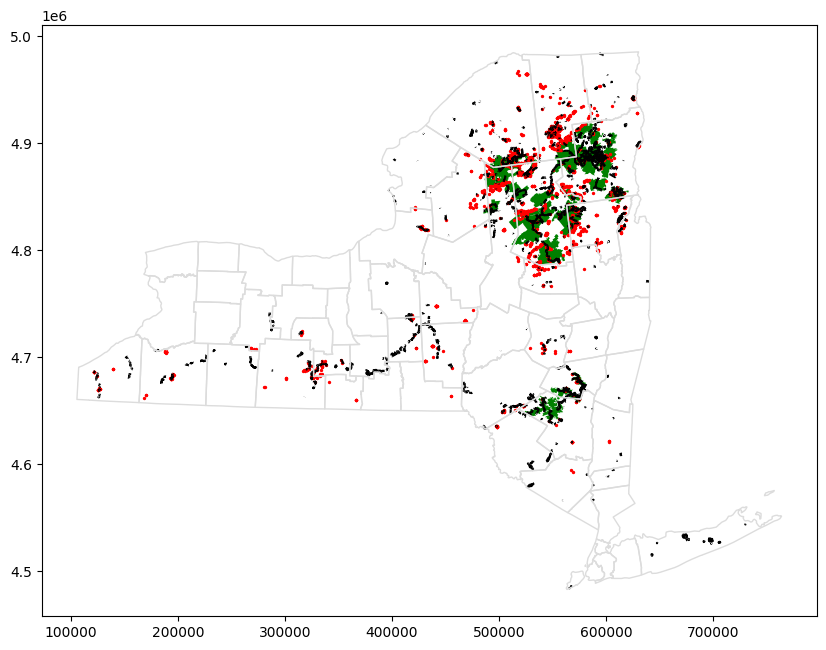

In [22]:
ax = counties.plot(figsize=(10, 10), color="None", edgecolor="gainsboro", zorder=3)

#plotting the wild_lands
wild_lands.plot(color="green", ax=ax)
#plotting campsites
campsites.plot(color="red", markersize=2, ax=ax)
#plotting foot trails
trails.plot(color="black", markersize=1, ax=ax)

Here we're creating maps in 2-d, but our world is actually a 3-d globe. So, we need to use a method called `map projection` to render it as a flat surface.

Map projections can't be 100% accurate, each projection distorts the surface of the earth in some way while retaining some useful property.

So, for that we use ***coordinate reference system (CRS)*** to show the projected points correspond to real locations on earth.

We can easily set the CRS in geopandas. For this we're going to load the shapefile containing regions of Ghana.

In [23]:
#loading the data
regions = gpd.read_file("/content/drive/MyDrive/data/ghana/ghana/Regions/Map_of_Regions_in_Ghana.shp")
regions.head()

,Region,geometry
0,Ashanti,"POLYGON ((686446.075 842986.894, 686666.193 84..."
1,Brong Ahafo,"POLYGON ((549970.457 968447.094, 550073.003 96..."
2,Central,"POLYGON ((603176.584 695877.238, 603248.424 69..."
3,Eastern,"POLYGON ((807307.254 797910.553, 807311.908 79..."
4,Greater Accra,"POLYGON ((858081.638 676424.913, 858113.115 67..."


In [24]:
#printing crs
regions.crs

<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Actually ***Coordinate Refernce Systems*** are refrenced by [European Petroleum Survey Group (EPSG)](https://epsg.io/) codes. And this DataFrame using `EPSG 32630` which is more commonly called the "Mercator" projection. This projection preserves angles (it's usefull for sea navigation) and slighly distorts area.

However, when creating a GeoDataFrame from a CSV file, we have to set the CRS.



## Creating GeoDataFrame from a CSV file

We're going to load a CSV file that contains the information about health facilities in GHANA for the reading of CSV file we need to use `Pands` library

In [25]:
#importing pandas and reading a CSV file
import pandas as pd

facilities_df = pd.read_csv("/content/drive/MyDrive/data/ghana/ghana/health_facilities.csv")
facilities_df.head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098


By using the above data we can create GeoDataFrame, for `geometry` we can use the columns `latitude` and `longitude`. And also we can use the parameter `crs` to set the crs value. Here we're going to use the ***EPSG 4326*** CRS code which is corresponds to coordinates in latitude and longitude

In [36]:
# converting DataFrame to GeoDataFrame
facilities = gpd.GeoDataFrame(facilities_df, geometry=gpd.points_from_xy(facilities_df.Longitude, facilities_df.Latitude))

In [37]:
# Filter out empty geometries
facilities = facilities[~facilities.geometry.is_empty]

In [38]:
#setting crs
facilities.crs = {"init":"epsg:4326"}

/usr/local/lib/python3.10/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [39]:
facilities.head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (-1.96317 7.40801)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (-1.58592 6.46312)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (-1.34982 6.22393)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)


In [40]:
facilities.crs

<Geographic 2D CRS: +init=epsg:4326 +type=crs>
Name: WGS 84
Axis Info [ellipsoidal]:
- lon[east]: Longitude (degree)
- lat[north]: Latitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Here you can see we successfully set the CRS to 4326

Actually regions GeoDataFrame crs is 32630, and facilities crs is 4326, so while the time of creating map it will give some errors. to fix that in GeoPandas we will use the `to_crs()` method for changing the CRS. Here before plotting the facilities to regions we are changing the crs to 32360 so it will correctly plot the data.

<Axes: >

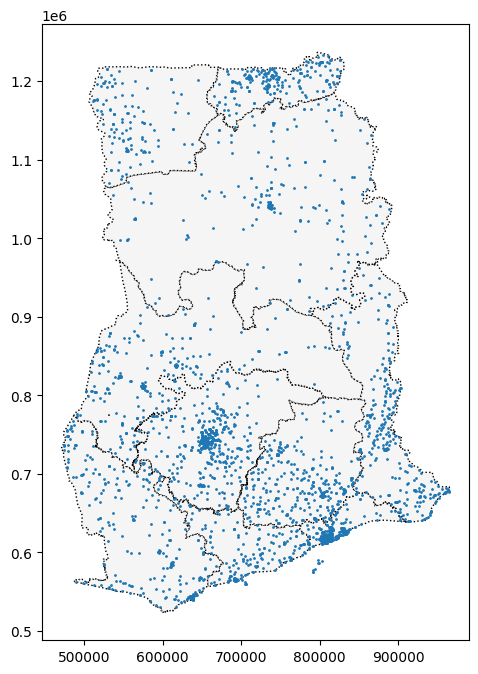

In [42]:
# Create a map
ax = regions.plot(figsize=(8,8), color='whitesmoke', linestyle=':', edgecolor='black')
facilities.to_crs(epsg=32630).plot(markersize=1, ax=ax)

`to_crs` method will modifies only the geometry column

In [43]:
# The "Latitude" and "Longitude" columns are unchanged
facilities.to_crs(epsg=32630).head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (614422.662 818986.851)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (656373.863 714616.547)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (682573.395 688243.477)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (653484.49 756478.812)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (653484.49 756478.812)


And also in some case the EPSG code is not available in GeoPandas, we can change the CRS with "proj4 string" of the CRS, the proj4 string to convert to latitude/longitude coordinates is as follows

```
+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs
```

In [44]:
# Change the CRS to EPSG 4326
regions.to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs").head()

,Region,geometry
0,Ashanti,"POLYGON ((-1.30985 7.62302, -1.30786 7.62198, ..."
1,Brong Ahafo,"POLYGON ((-2.54567 8.76089, -2.54473 8.76071, ..."
2,Central,"POLYGON ((-2.06723 6.29473, -2.06658 6.2942, -..."
3,Eastern,"POLYGON ((-0.21751 7.21009, -0.21747 7.20993, ..."
4,Greater Accra,"POLYGON ((0.23456 6.10986, 0.23484 6.10974, 0...."


***Attributes of geometric objects***

The type in "geometry" column depends on the what we are trying to show,

- ***Point*** : a point for the epicenter of an earthquake
- ***LineString*** : a linestring for a street
- ***Polygon*** : a polygon for country boundaries

All these 3 types of geometric objects have builtin attributes that you can use to quickly analyse the dataset.

You can get the `x` and `y` coordinates from Point like below:

In [45]:
# Get the x-coordinate of each point
facilities.geometry.head().x

,0
0,-1.96317
1,-1.58592
2,-1.34982
3,-1.61098
4,-1.61098


You can get the `length` from line string like below:

In [46]:
roads_trails.geometry.head().length

,0
0,1577.112643
1,945.366235
2,3853.119292
3,10485.458536
4,1432.490031


And you can get the `area` from polylgon

In [47]:
# Calculate the area (in square meters) of each polygon in the GeoDataFrame
regions.loc[:, "AREA"] = regions.geometry.area / 10**6

print("Area of Ghana: {} square kilometers".format(regions.AREA.sum()))
print("CRS:", regions.crs)
regions.head()

Area of Ghana: 239584.5760055668 square kilometers
CRS: EPSG:32630


,Region,geometry,AREA
0,Ashanti,"POLYGON ((686446.075 842986.894, 686666.193 84...",24379.017777
1,Brong Ahafo,"POLYGON ((549970.457 968447.094, 550073.003 96...",40098.168231
2,Central,"POLYGON ((603176.584 695877.238, 603248.424 69...",9665.626760
3,Eastern,"POLYGON ((807307.254 797910.553, 807311.908 79...",18987.625847
4,Greater Accra,"POLYGON ((858081.638 676424.913, 858113.115 67...",3706.511145
